In [4]:
%load_ext autoreload
%autoreload 2

In [9]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

sys.path.append('../')
from src.data_loader import fetch_stock_data

ko_data = fetch_stock_data("KO", "2020-01-01", "2024-01-01")
pep_data = fetch_stock_data("PEP", "2020-01-01", "2024-01-01")

df = pd.DataFrame({
    'KO': ko_data['Close'].squeeze(),
    'PEP': pep_data['Close'].squeeze()
}).dropna()

df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

,KO,PEP
Date,,
2020-01-02,44.873493,109.772476
2020-01-03,44.628689,109.618889
2020-01-06,44.612362,110.039162
2020-01-07,44.269634,108.309578
2020-01-08,44.351242,108.867264
...,...,...
2023-12-22,53.922443,151.618286
2023-12-26,54.144348,152.685242
2023-12-27,54.283035,153.173508


In [10]:
y = df['KO']

X = pd.DataFrame({
    'intercept': np.ones(df.shape[0]),
    'PEP': df['PEP']
})

X

,intercept,PEP
Date,,
2020-01-02,1.0,109.772476
2020-01-03,1.0,109.618889
2020-01-06,1.0,110.039162
2020-01-07,1.0,108.309578
2020-01-08,1.0,108.867264
...,...,...
2023-12-22,1.0,151.618286
2023-12-26,1.0,152.685242
2023-12-27,1.0,153.173508


In [11]:
model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                     KO   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     6976.
Date:                Sun, 04 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:27:29   Log-Likelihood:                -2217.4
No. Observations:                1006   AIC:                             4439.
Df Residuals:                    1004   BIC:                             4449.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      9.0719      0.484     18.740      0.0

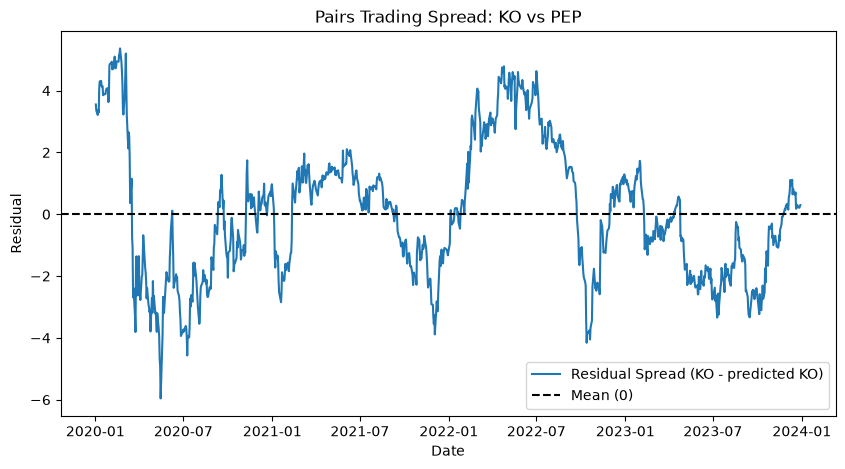

<Figure size 640x480 with 0 Axes>

In [14]:
spread = results.resid

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, spread, label='Residual Spread (KO - predicted KO)')

# Add a horizontal line at 0 for reference
ax.axhline(0, c='k', ls='--', label='Mean (0)')

ax.set_title("Pairs Trading Spread: KO vs PEP")
ax.set_ylabel("Residual")
ax.set_xlabel("Date")
ax.legend()
plt.show()

plt.savefig('../results/ko_pep_spread.png', dpi=400)

On reflection, it would be better to use a z-score instead of a hard number for the residual so that I can make a strategy that works across all pairs:

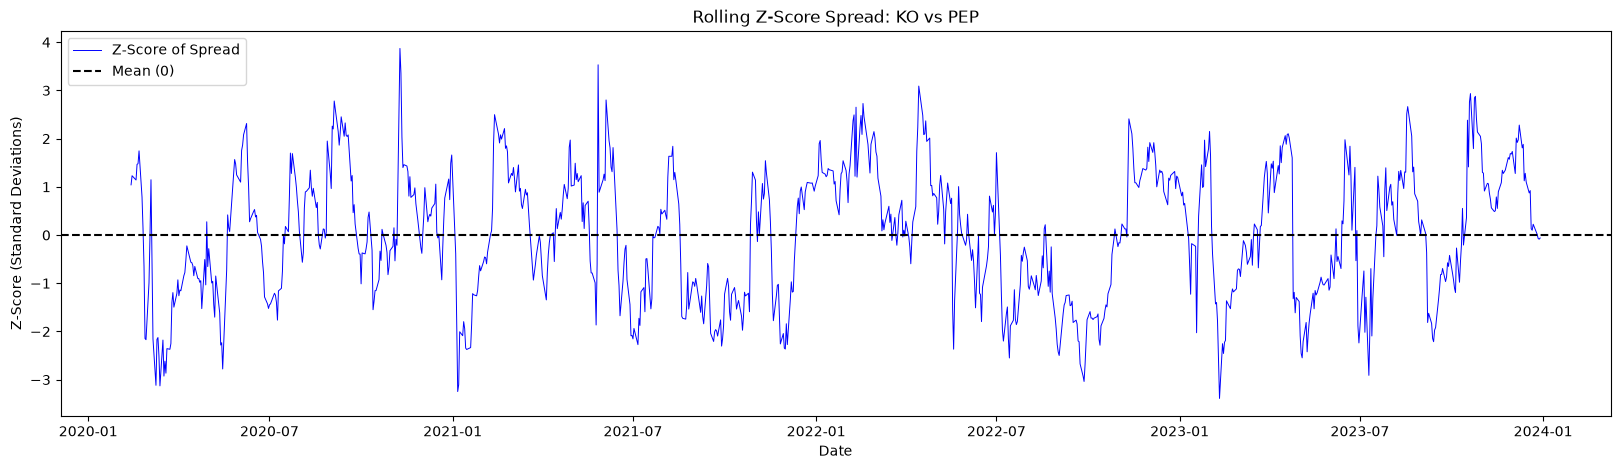

In [25]:
rolling_mean = spread.rolling(window=30).mean()
rolling_std = spread.rolling(window=30).std()

z_score = (spread - rolling_mean) / rolling_std

fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(df.index, z_score, label = 'Z-Score of Spread', color='blue', linewidth=0.7)

ax.axhline(0, c='k', ls='--', label='Mean (0)')

ax.set_title('Rolling Z-Score Spread: KO vs PEP')
ax.set_ylabel('Z-Score (Standard Deviations)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
plt.show()

fig.savefig('../results/ko_pep_spread_zscore.png', dpi=400)

When inspecting the chart it is clear that when |z|>2 there is a very quick reversion to the baseline. If |z|>2 then we short the overperforming asset and long the underperforming asset. The exit is when z approaches back to zero, for example when |z|<0.5>

After making a strategy and creating a backtest I will now run the backtest function:

KeyError: 'Portfolio Value'

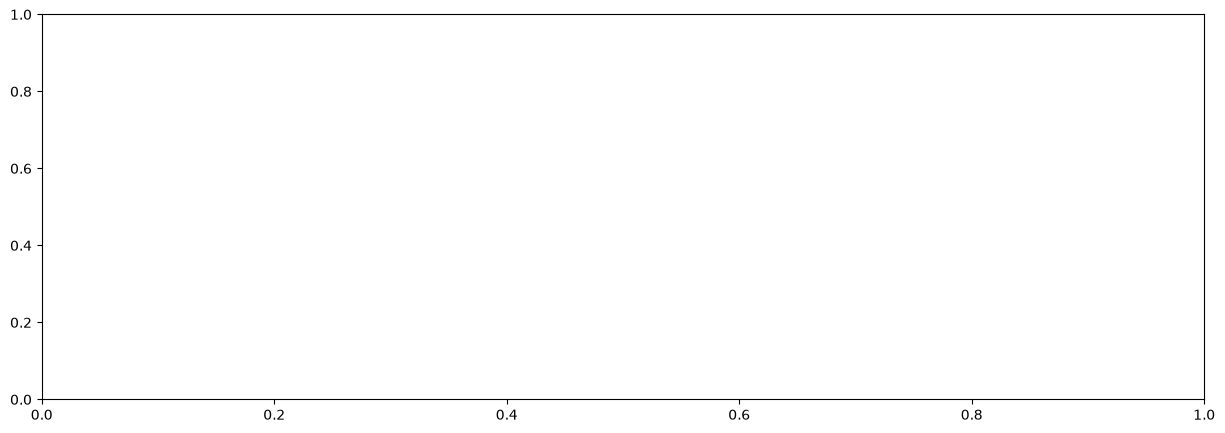

In [27]:
import matplotlib.pyplot as plt
from src.backtester import backtest_pairs_strategy

results_df = backtest_pairs_strategy(df, z_score, entry_threshold=2, exit_threshold=0.5)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(results_df.index, results_df['Portfolio Value'], label='Portfolio Value', color='blue')
ax.axhline(1.0, c='k', ls='--', label='Initial Value (1.0)')

ax.set_title('Cumulative Backtest Performance: KO vs PEP Pairs Strategy')
ax.set_ylabel('Portfolio Growth Multiplier')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
plt.show()